# Exercise: Derivatives

- by Börge Göbel

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

### Load data

In [2]:
data = np.loadtxt("04b_Exercise_velocity_acceleration_data_file.dat")

In [3]:
data

array([[  0.        ,   1.        ],
       [  0.1       ,   1.01980001],
       [  0.2       ,   1.03920011],
       ...,
       [ 99.8       ,  15.25565932],
       [ 99.9       ,  15.33160759],
       [100.        ,  15.40808206]], shape=(1001, 2))

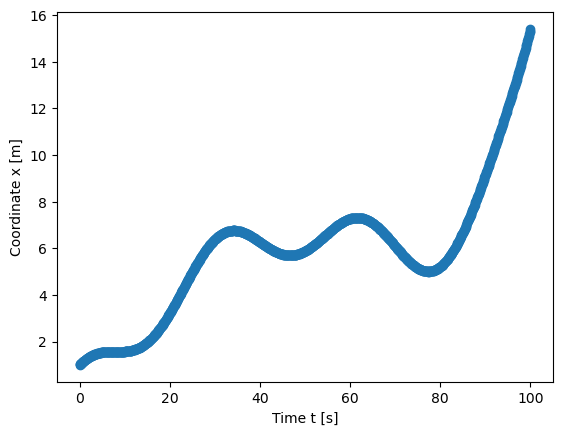

In [4]:
plt.xlabel('Time t [s]')
plt.ylabel('Coordinate x [m]')
plt.scatter(data[:,0],data[:,1])

### Task

Calculate the velocity \\(v(t)=\dot{x}(t)\\) and the acceleration \\(a(t)=\ddot{x}(t)\\) for the loaded data set that describes a set of points \\((t_i,x_i)\\) for \\(i=0,\dots,1000\\).

1. Calculate \\(v_i\\) and \\(a_i\\) using the forward-differences, central-differences and Richardson methods
2. Determine the maximum value of the acceleration and the corresponding time.

Be careful, now we do not know the function \\(x(t)\\) but only its values for specific points. You have to define the functions for the derivativesa bit differently.

### Solution

In [5]:
x_list = data[:, 0]

In [6]:
x_list

array([  0. ,   0.1,   0.2, ...,  99.8,  99.9, 100. ], shape=(1001,))

In [7]:
y_list = data[:, 1]

In [8]:
y_list

array([ 1.        ,  1.01980001,  1.03920011, ..., 15.25565932,
       15.33160759, 15.40808206], shape=(1001,))

In [29]:
h = 0.1
forward_list_v = []
for i in range(0, len(data[:, 1])-1):
    forward_vi = (y_list[i+1] - y_list[i]) / h 
    forward_list_v.append(forward_vi)
forward_v_last = (y_list[1000] - y_list[999]) / h
forward_list_v.append(forward_v_last)

In [30]:
forward_difference_v = np.array(forward_list_v)

In [31]:
forward_difference_v

array([0.19800007, 0.19400098, 0.19000427, ..., 0.75948268, 0.76474476,
       0.76474476], shape=(1001,))

In [33]:
central_list_v = []

central_v_first = (y_list[1] - y_list[0]) / (h)
central_list_v.append(central_v_first)

for i in range(1, len(data[:, 1])-1):
    central_vi = (y_list[i+1] - y_list[i-1]) / (2*h) 
    central_list_v.append(central_vi)
central_v_last = (y_list[1000] - y_list[999]) / (h)
central_list_v.append(central_v_last)

In [34]:
central_difference_v = np.array(central_list_v)

In [35]:
central_difference_v

array([0.19800007, 0.19600053, 0.19200263, ..., 0.75690408, 0.76211372,
       0.76474476], shape=(1001,))

In [36]:
D1Richardson_list_v = []

D1Richardson_first = (y_list[1] - y_list[0]) / h
D1Richardson_list_v.append(D1Richardson_first)

D1Richardson_second = (y_list[2] - y_list[1]) / h
D1Richardson_list_v.append(D1Richardson_second)

for i in range(2, len(data[:, 1]) - 2):
    D1Richardson_vi = 1/(12*h) * ( y_list[i-2] - 8*y_list[i-1] + 8*y_list[i+1] - y_list[i+2] )
    D1Richardson_list_v.append(D1Richardson_vi)

D1Richardson_second_to_last = (y_list[-2] - y_list[-3]) / h
D1Richardson_list_v.append(D1Richardson_second_to_last)

D1Richardson_last = (y_list[-1] - y_list[-2]) / h
D1Richardson_list_v.append(D1Richardson_last)

In [37]:
D1Richardson_v = np.array(D1Richardson_list_v)

In [38]:
D1Richardson_v

array([0.19800007, 0.19400098, 0.1920021 , ..., 0.75688667, 0.75948268,
       0.76474476], shape=(1001,))

In [42]:
forward_list_a = []

for i in range(0, len(data[:, 1]) - 2):
    forward_ai = ( y_list[i+2] - 2*y_list[i+1] + y_list[i] ) / h**2
    forward_list_a.append(forward_ai)

forward_second_to_last = ( y_list[-2] - 2*y_list[-3] + y_list[-4] ) / h**2
forward_list_a.append(forward_second_to_last)

forward_last = ( y_list[-1] - 2*y_list[-2] + y_list[-3] ) / h**2
forward_list_a.append(forward_last)

In [43]:
forward_difference_v = np.array(forward_list_a)

In [44]:
forward_difference_v

array([-0.03999081, -0.03996717, -0.03992779, ...,  0.05262077,
        0.05157192,  0.05262077], shape=(1001,))

In [46]:
central_list_a = []

central_first = ( y_list[2] - 2*y_list[1] + y_list[0] ) / h**2
central_list_a.append(central_first)

for i in range(1, len(data[:, 1]) - 1):
    central_ai = ( y_list[i+1] - 2*y_list[i] + y_list[i-1] ) / h**2
    central_list_a.append(central_ai)

central_last = ( y_list[-1] - 2*y_list[-2] + y_list[-3] ) / h**2
central_list_a.append(central_last)

In [47]:
central_difference_a = np.array(central_list_a)

In [48]:
central_difference_a

array([-0.03999081, -0.03999081, -0.03996717, ...,  0.05157192,
        0.05262077,  0.05262077], shape=(1001,))

In [55]:
D2Richardson_list_a = []

D2Richardson_first_a = ( y_list[2] - 2*y_list[1] + y_list[0] ) / h**2
D2Richardson_list_a.append(D2Richardson_first_a)

D2Richardson_second_a = ( y_list[2] - 2*y_list[1] + y_list[0] ) / h**2
D2Richardson_list_a.append(D2Richardson_second_a)

for i in range(2, len(data[:, 1]) - 2):
    D2Richardson_ai = 1/(12*h**2) * ( -y_list[i-2] + 16*y_list[i-1] - 30*y_list[i] + 16*y_list[i+1] - y_list[i+2] )
    D2Richardson_list_a.append(D2Richardson_ai)

D2Richardson_second_to_last_a = ( y_list[-1] - 2*y_list[-2] + y_list[-3] ) / h**2
D2Richardson_list_a.append(D2Richardson_second_to_last_a)

D2Richardson_last_a = ( y_list[-1] - 2*y_list[-2] + y_list[-3] ) / h**2
D2Richardson_list_a.append(D2Richardson_last_a)

In [56]:
D2Richardson_a = np.array(D2Richardson_list_a)

In [57]:
D2Richardson_a

array([-0.03999081, -0.03999081, -0.03996848, ...,  0.05157125,
        0.05262077,  0.05262077], shape=(1001,))

In [58]:
np.max(D2Richardson_a)

np.float64(0.058898336150988335)

In [65]:
np.argmax(D2Richardson_a)

np.int64(796)

In [66]:
x_list[796]

np.float64(79.60000000000001)